## Linear regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
rng = np.random.default_rng(seed=52)
m = 200
X = 2 * rng.random((m, 1))
y = 4 + 3*X + rng.standard_normal((m, 1))

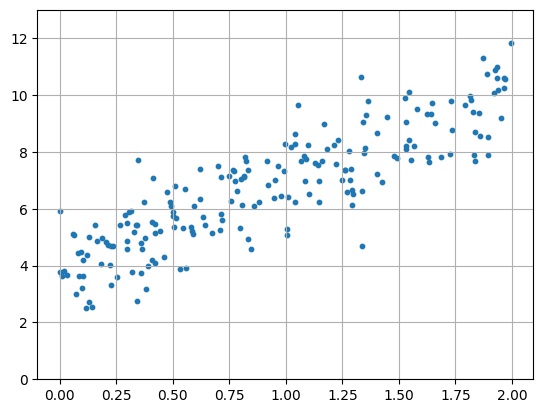

In [4]:
plt.scatter(X, y, s=10)
plt.ylim(0, 13)
plt.grid(True)

plt.show()

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mrow>
    <mover accent="true"><mi mathvariant="bold">θ</mi> <mo>^</mo></mover>
    <mo>=</mo>
    <msup><mrow><mo>(</mo><msup><mi mathvariant="bold">X</mi> <mo>⊺</mo> </msup><mi mathvariant="bold">X</mi><mo>)</mo></mrow> <mrow><mo>-</mo><mn>1</mn></mrow> </msup>
    <msup><mi mathvariant="bold">X</mi> <mo>⊺</mo> </msup>
    <mi mathvariant="bold">y</mi>
  </mrow>
</math>

In [5]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)

theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
theta_best

array([[3.92380655],
       [3.05613467]])

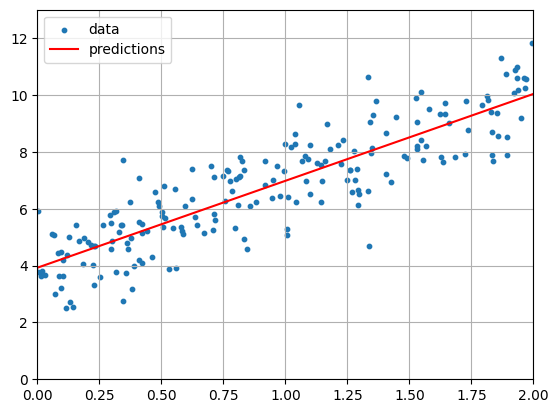

In [5]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_pred = X_new_b @ theta_best

plt.scatter(X, y, s=10, label='data')
plt.plot(X_new, y_pred, 'r-', label='predictions')

plt.ylim(0, 13)
plt.xlim(0, 2)
plt.grid(True)
plt.legend()

plt.show()

In [6]:
#exactly the same results as I did manually
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print(lin_reg.intercept_, lin_reg.coef_)
print(lin_reg.predict(X_new))

[3.92380655] [[3.05613467]]
[[ 3.92380655]
 [10.03607589]]


<math xmlns="http://www.w3.org/1998/Math/MathML"><mover accent="true"><mi mathvariant="bold">θ</mi><mo>^</mo></mover><mo>=</mo><msup><mi mathvariant="bold">X</mi><mo>+</mo></msup><mi mathvariant="bold">y</mi></math>

In [7]:
#sklearn's lin_reg is based on this numpy function but wit a pseudo inverse
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[3.92380655],
       [3.05613467]])

In [8]:
## lstsq is based on this

theta_best_pinv = np.linalg.pinv(X_b) @ y
theta_best_pinv

array([[3.92380655],
       [3.05613467]])

#### Batch GD

<math xmlns="http://www.w3.org/1998/Math/MathML" display="block">
  <mrow>
    <msub><mi>∇</mi> <mi mathvariant="bold">θ</mi> </msub>
    <mspace width="0.166667em"></mspace>
    <mtext>MSE</mtext>
    <mrow>
      <mo>(</mo>
      <mi mathvariant="bold">θ</mi>
      <mo>)</mo>
    </mrow>
    <mo>=</mo>
<mrow>
<mo stretchy="true">(</mo>
      <mtable>
        <mtr>
          <mtd>
            <mrow>
              <mfrac><mi>∂</mi> <mrow><mi>∂</mi><msub><mi>θ</mi> <mn>0</mn> </msub></mrow></mfrac>
              <mtext>MSE</mtext>
              <mrow>
                <mo>(</mo>
                <mi mathvariant="bold">θ</mi>
                <mo>)</mo>
              </mrow>
            </mrow>
          </mtd>
        </mtr>
        <mtr>
          <mtd>
            <mrow>
              <mfrac><mi>∂</mi> <mrow><mi>∂</mi><msub><mi>θ</mi> <mn>1</mn> </msub></mrow></mfrac>
              <mtext>MSE</mtext>
              <mrow>
                <mo>(</mo>
                <mi mathvariant="bold">θ</mi>
                <mo>)</mo>
              </mrow>
            </mrow>
          </mtd>
        </mtr>
        <mtr>
          <mtd>
            <mo>⋮</mo>
          </mtd>
        </mtr>
        <mtr>
          <mtd>
            <mrow>
              <mfrac><mi>∂</mi> <mrow><mi>∂</mi><msub><mi>θ</mi> <mi>n</mi> </msub></mrow></mfrac>
              <mtext>MSE</mtext>
              <mrow>
                <mo>(</mo>
                <mi mathvariant="bold">θ</mi>
                <mo>)</mo>
              </mrow>
            </mrow>
          </mtd>
        </mtr>
      </mtable>
    <mo stretchy="true">)</mo>
</mrow>
    <mo>=</mo>
    <mstyle scriptlevel="0" displaystyle="true">
      <mfrac><mn>2</mn> <mi>m</mi></mfrac>
    </mstyle>
    <msup><mi mathvariant="bold">X</mi> <mo>⊺</mo> </msup>
    <mrow>
      <mo>(</mo>
      <mi mathvariant="bold">X</mi>
      <mi mathvariant="bold">θ</mi>
      <mo>-</mo>
      <mi mathvariant="bold">y</mi>
      <mo>)</mo>
    </mrow>
  </mrow>
</math>

In [9]:
eta = 0.1
m = len(X_b)
n_epochs = 1000

rng = np.random.default_rng(seed=52)
theta = rng.standard_normal((2,1))


for epoch in range(n_epochs):
    gradient = 2/m * X_b.T @ (X_b @ theta - y)
    theta = theta - eta*gradient

In [10]:
theta

array([[3.92380655],
       [3.05613467]])

In [11]:
#Stochatic GD
n_epochs = 50
t0, t1 = 5, 50

rng = np.random.default_rng(seed=52)
theta = rng.standard_normal((2,1))

def learning_schedule(t):
    return t0 / (t+t1)

for epoch in range(n_epochs):
    for itr in range(m):
        random_num = rng.integers(m)
        x_i = X_b[random_num : random_num + 1]
        y_i = y[random_num : random_num + 1]
        gradient = 2* x_i.T @ (x_i @ theta - y_i)
        eta = learning_schedule(epoch * m + itr)
        theta = theta - eta * gradient
        
theta

array([[3.97662136],
       [3.04677317]])

In [12]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(penalty=None, max_iter=1000, tol=1e-5, eta0=0.01, n_iter_no_change=50, random_state=52)

sgd_reg.fit(X, y)

sgd_reg.intercept_, sgd_reg.coef_

/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


(array([3.92275164]), array([3.05723246]))

### polynomial regression

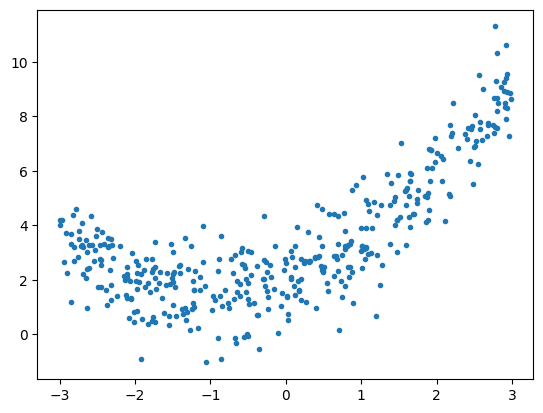

In [13]:
rng = np.random.default_rng(seed=52)
m = 400

X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X**2 + X + 2 + rng.standard_normal((m, 1)) 

plt.scatter(X, y, s=9)

In [14]:
from sklearn.preprocessing import PolynomialFeatures

poly_f = PolynomialFeatures(degree=2, include_bias=False)

X_poly = poly_f.fit_transform(X)

print(X[0])
print(X_poly[0])

[0.69457773]
[0.69457773 0.48243822]


[2.024] [[0.96  0.486]]


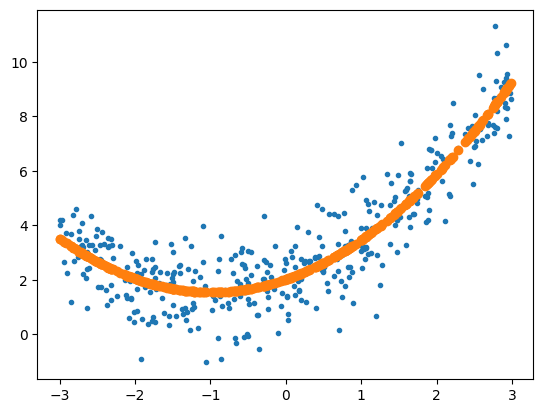

In [15]:
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
y_pred = lin_reg.predict(X_poly)

plt.scatter(X, y, s=9)
plt.scatter(X, y_pred, colorizer='red')

print(lin_reg.intercept_.round(3), lin_reg.coef_.round(3))
plt.show()

### Learning curves

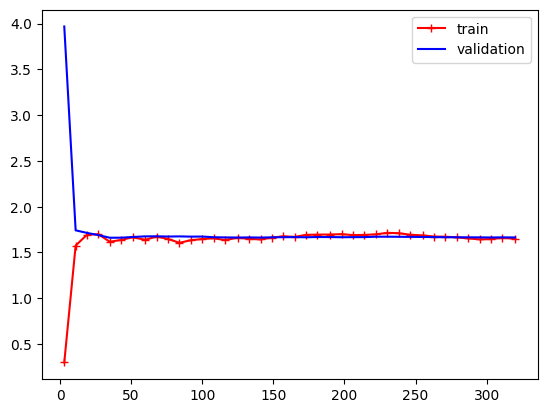

In [16]:
#underfitting
from sklearn.model_selection import learning_curve

train_size, train_score, val_score = learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1, 40), 
                                                    cv=5, scoring='neg_root_mean_squared_error')

train_score = -train_score.mean(axis=1)
val_score = -val_score.mean(axis=1)

plt.plot(train_size, train_score, 'r-+', label='train')
plt.plot(train_size, val_score, 'b-', label='validation')

plt.legend()
plt.show()

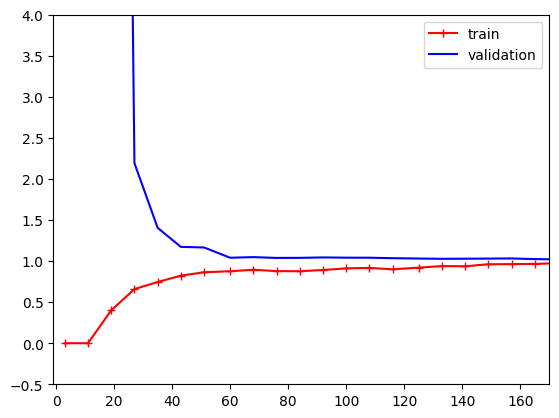

In [17]:
#overfitting
from sklearn.pipeline import make_pipeline

poly_reg = make_pipeline(PolynomialFeatures(degree=10, include_bias=False), LinearRegression())


train_size, train_score, val_score = learning_curve(poly_reg, X, y, train_sizes=np.linspace(0.01, 1, 40), 
                                                    cv=5, scoring='neg_root_mean_squared_error')

train_score = -train_score.mean(axis=1)
val_score = -val_score.mean(axis=1)

plt.plot(train_size, train_score, 'r-+', label='train')
plt.plot(train_size, val_score, 'b-', label='validation')

plt.legend()
plt.xlim(-1, 170)
plt.ylim(-0.5, 4)

plt.show()

### Regularized linear models

In [18]:
#Ridge reggresion
from sklearn.linear_model import Ridge

rg_reg = Ridge(alpha=0.1, solver='cholesky')

rg_reg.fit(X, y)
rg_reg.predict([[1.5]])

array([4.90130365])

In [19]:
#for SGD

rg_reg = SGDRegressor(penalty="l2", alpha=0.1/m, random_state=52, tol=None, eta0=0.01, max_iter=1000)

rg_reg.fit(X, y)
rg_reg.predict([[1.5]])

/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([4.89668732])

In [20]:
# lasso reggresion
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([4.84836757])

In [21]:
# elastic net reggresion
from sklearn.linear_model import ElasticNet

elastic_reg = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_reg.fit(X, y)
elastic_reg.predict([[1.5]])

array([4.85053591])

#### Early stop

In [22]:
from copy import deepcopy
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.15)

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False), StandardScaler())

X_tp = preprocessing.fit_transform(X_train)
X_vp = preprocessing.transform(X_valid)

sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=52)

n_epochs = 500
best_valid_rmse = float('inf')
epoch_it = 0

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_tp, y_train)
    y_predicted = sgd_reg.predict(X_vp) 
    rmse_score = root_mean_squared_error(y_valid, y_predicted)
    if rmse_score < best_valid_rmse:
        best_valid_rmse = rmse_score
        best_model = deepcopy(sgd_reg)
        epoch_it = epoch
        


/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Ple

In [23]:
best_model.predict(preprocessing.transform([[1.5]]))

array([4.34934234])

In [24]:
#it was the middle, if we'd continued the model would have been worse
epoch_it

232

### Logistic Regression practice

In [25]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
print(list(iris))
print(iris.data.head(5))

['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2


In [26]:
print(iris.target_names)
print(iris.target.head(5))

['setosa' 'versicolor' 'virginica']
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64


In [27]:
from sklearn.linear_model import LogisticRegression

X = iris.data[['petal width (cm)']].values
y = iris.target_names[iris.target] == 'virginica'

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=52)

log_reg = LogisticRegression(random_state=52)

log_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,52
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


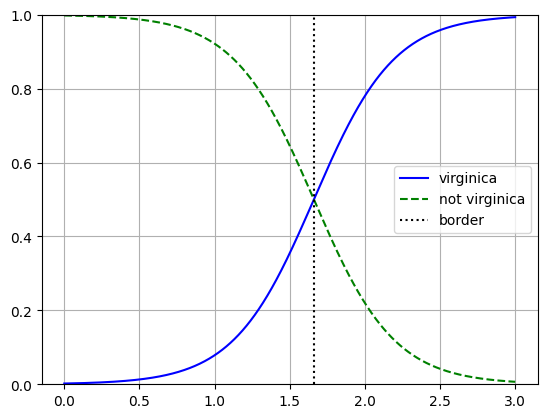

In [28]:
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_border = X_new[y_proba[:, 1] >= 0.5][0, 0]

plt.plot(X_new, y_proba[:, 1], 'b-', label='virginica')
plt.plot(X_new, y_proba[:, 0], 'g--', label='not virginica')
plt.plot([decision_border, decision_border], [0,1], 'k:', label='border')

plt.ylim(0,1)
plt.grid(True)
plt.legend()

plt.show()

In [29]:
print(decision_border)
print(log_reg.predict([[1.5], [1.7]]))

1.6606606606606606
[False  True]


### Softmax regressor

In [30]:
X = iris.data[['petal length (cm)', 'petal width (cm)']]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=52)

softmax_reg = LogisticRegression(C=30, random_state=52)
softmax_reg.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,30
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,52
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [31]:
print(softmax_reg.predict([[5, 2]]))
softmax_reg.predict_proba([[5, 2]]).round(3)

[2]


/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/damian/test/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([[0.   , 0.035, 0.965]])

In [32]:
from sklearn.model_selection import cross_val_score

cross_val_score(softmax_reg, X_train, y_train, cv=5, scoring='accuracy')

array([0.95652174, 0.86956522, 0.95454545, 1.        , 1.        ])

In [33]:
y_pred = softmax_reg.predict(X_train)

(y_pred - y_train).mean()

np.float64(0.008928571428571428)

# Ex 12

In [34]:
X = iris.data[['petal length (cm)', 'petal width (cm)']].values
y = iris['target'].values

In [35]:
X_bias = np.c_[np.ones(len(X)), X]

In [36]:
test_ratio = 0.2
valid_ratio = 0.2
total_size = len(X)

test_size = int(total_size * test_ratio)
valid_size = int(total_size * valid_ratio)
train_size = total_size - test_size - valid_size 

rng = np.random.default_rng(seed=52)
rng_indexes = rng.permutation(total_size)

X_train = X_bias[rng_indexes[:train_size]]
y_train = y[rng_indexes[:train_size]]
X_valid = X_bias[rng_indexes[train_size:valid_size+train_size]]
y_valid = y[rng_indexes[train_size:valid_size+train_size]]
X_test = X_bias[rng_indexes[train_size+valid_size:]]
y_test = y[rng_indexes[train_size+valid_size:]]


In [37]:
def to_one_hot(y):
    return np.diag(np.ones(y.max()+1))[y]

In [38]:
to_one_hot(y_train[:10])

array([[0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.],
       [0., 0., 1.],
       [1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.]])

In [39]:
y_train_mod = to_one_hot(y_train)
y_valid_mod = to_one_hot(y_valid)
y_test_mod  = to_one_hot(y_test)

In [40]:
mean = X_train[:, 1:].mean(axis=0)
std = X_train[:, 1:].std(axis=0)

X_train[:, 1:] = (X_train[:, 1:] - mean)/std
X_valid[:, 1:] = (X_valid[:, 1:] - mean)/std
X_test[:, 1:]  = (X_test[:, 1:] - mean) /std

In [41]:
def softmax(logits):
    exps = np.exp(logits)
    exp_sum = exps.sum(axis=1, keepdims=True)
    return exps / exp_sum

In [42]:
n_inputs = X_train.shape[1]
n_outputs = len(np.unique(y_train))
print(n_inputs, n_outputs)

3 3


In [43]:
eta = 0.5
n_epochs = 5001
epsilon = 1e-5
m=len(X_train)

rng = np.random.default_rng(seed=52)
theta = rng.standard_normal((n_inputs, n_outputs))

for epoch in range(n_epochs):
    logits = X_train @ theta
    y_proba = softmax(logits)
    if epoch % 1000 == 0:
        y_proba_valid = softmax(X_valid @ theta)
        losses = -(y_valid_mod * np.log(y_proba_valid + epsilon))
        print(epoch, losses.sum(axis=1).mean())
    error = y_proba - y_train_mod
    gradients = 1 / m * X_train.T @ error
    theta = theta - eta * gradients
    
    
    

0 1.3876191508998592
1000 0.12769802421536708
2000 0.12855648985373722
3000 0.1328264270695111
4000 0.1371258186520424
5000 0.1410501834006256


In [44]:
theta

array([[-2.04234197,  5.45617619, -4.06112983],
       [-6.82680321, -1.56727024,  9.28911672],
       [-6.05843343, -0.3778163 ,  5.66678323]])

In [45]:
logits = X_valid @ theta
y_proba = softmax(logits)
y_predict = y_proba.argmax(axis=1)

accuracy_score = (y_predict==y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

In [46]:
#with l2 regularization
eta = 0.5
n_epochs = 5001
epsilon = 1e-5
m=len(X_train)
alpha = 0.01

rng = np.random.default_rng(seed=52)
theta = rng.standard_normal((n_inputs, n_outputs))

for epoch in range(n_epochs):
    logits = X_train @ theta
    y_proba = softmax(logits)
    if epoch % 1000 == 0:
        y_proba_valid = softmax(X_valid @ theta)
        l2 = 1/2 * (theta[1:]**2).sum()
        losses = -(y_valid_mod * np.log(y_proba_valid + epsilon))
        total_losse = losses.sum(axis=1).mean() * alpha * l2
        print(epoch, total_losse.round(4))
    error = y_proba - y_train_mod
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), alpha * theta[1:]]
    theta = theta - eta * gradients
    

0 0.0133
1000 0.0209
2000 0.0209
3000 0.0209
4000 0.0209
5000 0.0209


In [47]:
theta

array([[-1.05750433,  1.46493233, -1.05472361],
       [-2.25571965,  0.08861894,  2.1671007 ],
       [-2.05748057, -0.30291217,  2.36039274]])

In [48]:
logits = X_valid @ theta
y_proba = softmax(logits)
y_predict = y_proba.argmax(axis=1)

accuracy_score = (y_predict==y_valid).mean()
accuracy_score

np.float64(0.9333333333333333)

In [58]:
eta = 0.5
n_epochs = 5001
epsilon = 1e-5
m=len(X_train)
C=100
best_loss = np.inf

rng = np.random.default_rng(seed=52)
theta = rng.standard_normal((n_inputs, n_outputs))

for epoch in range(n_epochs):
    logits = X_train @ theta
    y_proba = softmax(logits)
    
    y_proba_valid = softmax(X_valid @ theta)
    l2 = 1/2 * (theta[1:]**2).sum()
    losses = -(y_valid_mod * np.log(y_proba_valid + epsilon))
    total_losse = losses.sum(axis=1).mean() + 1 / C * l2
    if epoch % 1000 == 0:
        print(epoch, total_losse.round(4))
    if total_losse < best_loss:
        best_loss = total_losse
    else:
        print(epoch - 1, best_loss.round(4))
        print(epoch, total_losse.round(4), 'early stop!')
        break
    error = y_proba - y_train_mod
    gradients = 1 / m * X_train.T @ error
    gradients += np.r_[np.zeros([1, n_outputs]), 1/C * theta[1:]]
    theta = theta - eta * gradients
    


0 1.3972
780 0.3106
781 0.3106 early stop!


In [66]:
import matplotlib as mpl

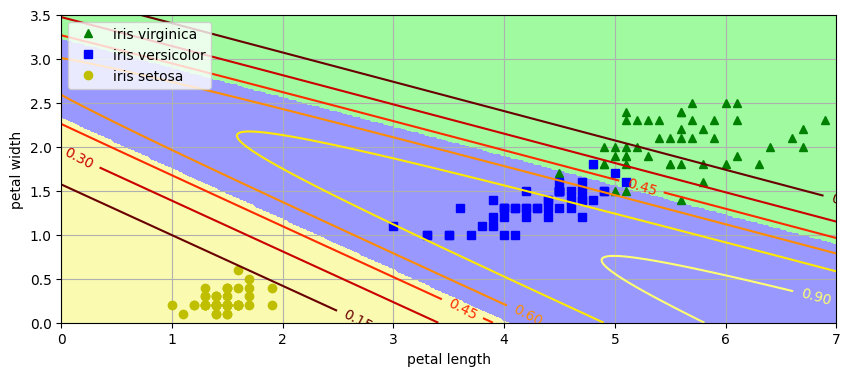

In [76]:
custom_cmap = mpl.colors.ListedColormap(['#fafab0', '#9898ff', '#a0faa0'])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1), np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]
X_new = (X_new - mean) / std
X_new_bias = np.c_[np.ones(len(X_new)), X_new]

logits = X_new_bias @ theta
y_proba = softmax(logits)
y_pred = y_proba.argmax(axis=1)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_pred.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[y==2, 0], X[y==2, 1], 'g^', label='iris virginica')
plt.plot(X[y==1, 0], X[y==1, 1], 'bs', label='iris versicolor')
plt.plot(X[y==0, 0], X[y==0, 1], 'yo', label='iris setosa')

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap='hot')
plt.clabel(contour, inline=1)

plt.xlabel('petal length')
plt.ylabel('petal width')
plt.axis([0, 7, 0, 3.5])
plt.legend(loc='upper left')
plt.grid(True)

plt.show()

In [77]:
logits = X_test @ theta
y_proba = softmax(logits)
y_predict = y_proba.argmax(axis=1)

accuracy_score = (y_predict==y_test).mean()
accuracy_score

np.float64(1.0)